## Example of SDE-matching using a Gaussian Process as marginal distribution

We define a data generating process by the following SDE:
$$
dz_t = f(z_t, t) dt + g(z_t, t) dW_t = \begin{bmatrix}
0 & 2 \\
-2 & 0
\end{bmatrix} z_t d_t + 0.6 \cdot dWt
$$

with emission distribution $y_t \sim \mathcal N(y_t\vert z_t, 0.3^2)$ and initial conditions: $z_0 \sim \mathcal N(0, I_2)$

In [1]:

import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import matplotlib
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from SDEmatching.distributions.Emission import GaussianEmission
from SDEmatching.distributions.Prior import GaussianPrior
from SDEmatching.core.Diffusions import ScalarDiffusion, SimpleDiffusion
from models import FunctionApproximatorModel, FunctionApproximatorModel_drift
from SDEmatching.core.Marginal import Marginal
from SDEmatching.models.Flows import DDPMflow, NormalFlow, AffineFlow
from SDEmatching.core.SDE import SimpleSDE, SDE, manual_euler_sample
from SDEmatching.utils.utils import torch_seed, to_tensor, mask_and_pad
import seaborn as sns
from SDEmatching.utils.datageneration import SDEdatagenerator
from SDEmatching.core.SDEproblem import SDEproblem
from plot_functions import plot_parameter_history, plot_marginal
from SDEmatching.models.ConditionMappers import TransformerLatentModel

import numpy as np
import normflows as nf
from torch.utils.data import DataLoader, TensorDataset
import copy
import pandas as pd
#torch.autograd.set_detect_anomaly(True)

In [2]:
# set constants
num_timesteps = 30
num_ts_samples = 30
num_series = 20
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'

state_dim = 2
observation_dim = state_dim
t_start = -1
t_end = 1
time_dist = torch.distributions.Uniform(t_start, t_end)

true_diffusion_log_std = torch.tensor(.3).log()
true_prior_log_std = (torch.ones(state_dim, device=device)).log()
true_emission_log_std = torch.tensor(.3).log()

In [3]:
"""
Generating data
"""

# diffusion function  
generator_diffusion = SimpleDiffusion(brownian_dim=2, state_dim=state_dim, log_std=true_diffusion_log_std, device=device, trainable=True)

# drift function
#generator_drift = SimpleDrift(dim=state_dim, device=device)
generator_drift = FunctionApproximatorModel_drift(num_features=state_dim, hidden_layers=[], 
                                                  num_outputs=state_dim, nonlin=torch.nn.ReLU(), seed=2, 
                                                  initial_zero=False, device=device, time_independent=True, bias=False)
generator_drift.hidden_layers[0].weight.data = torch.tensor([[0., 2.], [-2., 0.]], device=device)

# prior
generator_prior = GaussianPrior(mean=torch.ones(state_dim, device=device) * 0., log_std=true_prior_log_std, device=device, trainable=True)

# emission distribution:
generator_emission = GaussianEmission(dim=state_dim, log_std=true_emission_log_std, device=device, trainable=True)

# put together the SDE
generator_SDE = SDE(generator_drift, generator_diffusion, generator_prior, steps=num_timesteps, t_start=t_start, t_end=t_end, device=device)
#list_of_timeseries = SDEdatagenerator(generator_SDE, generator_emission, time_dist, num_series=11, mean_num_ts=10, same_ts=False, num_ts_samples=None, device=device)

# generate data
#list_of_timeseries, list_of_state_timeseries = SDEdatagenerator(generator_SDE, generator_emission, time_dist, num_series=num_series, same_ts=False, num_ts_samples=num_ts_samples, device=device, seed=2)
list_of_timeseries, list_of_state_timeseries = SDEdatagenerator(generator_SDE, generator_emission, time_dist, num_series=num_series, same_ts=False, mean_num_ts=num_ts_samples, device=device, seed=2)


In [4]:
true_state_series = torch.stack([state_timeseries for state_timeseries in list_of_state_timeseries]).detach().clone()
data, emissions_mask = mask_and_pad(list_of_timeseries, list_of_state_timeseries, state_dim, device)

/var/folders/t_/nfzp77bj23v7ypcy679dgp_80000gn/T/ipykernel_20521/2287495631.py:13: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4483.)
  _=plt.plot(data[i, ~emissions_mask[i],0].T.detach().cpu(), data[i, ~emissions_mask[i],1].T.detach().cpu(), marker="x", linewidth=0, c=color, label=emmission_label)


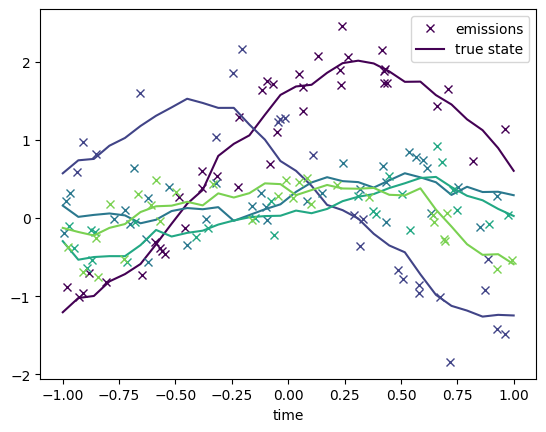

In [5]:
# Plotting some paths and emissions
cmap = matplotlib.colormaps["viridis"]
series_to_plot=min(5, data.shape[0])
for i in range(series_to_plot):
    color = cmap(i/series_to_plot)
    if i == 0:
        emmission_label = "emissions"
        state_label = "true state"
    else:        
        emmission_label = None
        state_label = None
    
    _=plt.plot(data[i, ~emissions_mask[i],0].T.detach().cpu(), data[i, ~emissions_mask[i],1].T.detach().cpu(), marker="x", linewidth=0, c=color, label=emmission_label)
    _=plt.plot(generator_SDE.ts.detach().cpu(), true_state_series[i,:,0].T.detach().cpu(), marker="", c=color, label=state_label)
    plt.xlabel("time")
    plt.legend()
plt.show()

## Define model setup for training
We define a model of the same class as the generating model:
$$
dz_t = f(z_t, t) dt + g(z_t, t) dW_t = A_\theta z_t d_t + \sigma_\theta \cdot dWt
$$

with emission distribution: $y_t \sim \mathcal N(y_t\vert z_t, \sigma^2_y)$ and initial conditions: $z_0 \sim \mathcal N(\mu_I, \sigma^2_I \cdot I_2)$

For now,  we initialize the parameters $A_\theta$, $\log \sigma_\theta$, $\log \sigma_y$, $\mu_I$ and $\log \sigma_I$ to the true valuse.

In [6]:
# Prior
priormean = torch.zeros(state_dim, device=device)
prior_log_std = true_prior_log_std.clone().detach()
myprior = GaussianPrior(mean=priormean, log_std=prior_log_std, trainable=True, device=device)

# Diffusion term
mydiffusion = SimpleDiffusion(state_dim, state_dim, log_std=true_diffusion_log_std.clone().detach(), device=device, trainable=True)

# Drift term
mydrift = FunctionApproximatorModel_drift(num_features=state_dim, hidden_layers=[], num_outputs=state_dim, nonlin=torch.nn.ReLU(), seed=2, initial_zero=False, device=device, time_independent=True, bias=False)

# Emission distribution:
myemission = GaussianEmission(dim=state_dim, log_std=true_emission_log_std.clone().detach(), trainable=True, device=device)


## Building the marginal distribution

In [7]:
condition_mapper = TransformerLatentModel(obs_dim=state_dim, state_dim=state_dim, model_dim=128, time_embed_dim=32, n_heads=4, n_layers=3).to(device)
marginal_func = AffineFlow(state_dim, device=device)
myMarginal = Marginal(marginal_func, mydiffusion, condition_mapper, device=device)


In [8]:

mySDEproblem = SDEproblem(drift=mydrift, 
                          diffusion=mydiffusion, 
                          prior=myprior, 
                          marginal_func=marginal_func, 
                          condition_mapper=condition_mapper, 
                          emission=myemission, 
                          time_dist=time_dist, 
                          t_start=t_start, 
                          t_end=t_end, 
                          device=device)

print(f"Total parameters in mySDEproblem: {sum(p.numel() for p in mySDEproblem.parameters())}")
for k in dict(mySDEproblem.named_parameters()).keys():
    print(k)

print("\n\nGenerating modules parameters")
for net in [generator_drift, generator_diffusion, generator_emission, generator_prior]:
    print(f"\n{net._get_name()}:")
    print(dict(net.named_parameters()))

print("\n\nSolving modules parameters")
for net in [mydrift, mydiffusion, myemission, myprior]:
    print(f"\n{net._get_name()}:")
    print(dict(net.named_parameters()))

Total parameters in mySDEproblem: 616782
drift.hidden_layers.0.weight
diffusion.log_std
prior.log_std
prior.mean
condition_mapper.encoder.embedding.time_mlp.0.weight
condition_mapper.encoder.embedding.time_mlp.0.bias
condition_mapper.encoder.embedding.time_mlp.2.weight
condition_mapper.encoder.embedding.time_mlp.2.bias
condition_mapper.encoder.embedding.data_proj.weight
condition_mapper.encoder.embedding.data_proj.bias
condition_mapper.encoder.encoder.layers.0.self_attn.in_proj_weight
condition_mapper.encoder.encoder.layers.0.self_attn.in_proj_bias
condition_mapper.encoder.encoder.layers.0.self_attn.out_proj.weight
condition_mapper.encoder.encoder.layers.0.self_attn.out_proj.bias
condition_mapper.encoder.encoder.layers.0.linear1.weight
condition_mapper.encoder.encoder.layers.0.linear1.bias
condition_mapper.encoder.encoder.layers.0.linear2.weight
condition_mapper.encoder.encoder.layers.0.linear2.bias
condition_mapper.encoder.encoder.layers.0.norm1.weight
condition_mapper.encoder.encoder

In [9]:
# Saving true parameters to list, for plotting
def save_models(parameter_dict, models_to_be_saved):
    for model_to_be_saved in models_to_be_saved:
        for parameter_name, parameter_value in model_to_be_saved.named_parameters():
            if parameter_value.data.dim:
                val = parameter_value.data.unsqueeze(0)
            else: val = parameter_value.data
            val = val.ravel().unsqueeze(0)
            fullname = f"{model_to_be_saved._get_name()}.{parameter_name}"
            if fullname in parameter_dict.keys():
                parameter_dict[fullname] = torch.cat([parameter_dict[fullname], val.clone().detach()])
            else: parameter_dict[fullname] = val.clone().detach()

true_parameter_dict ={}
save_models(true_parameter_dict, [generator_drift, generator_diffusion, generator_emission, generator_prior])

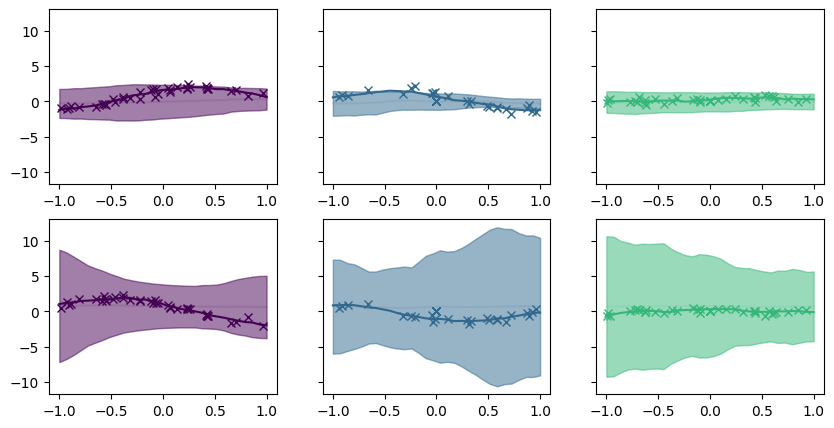

In [10]:
# Plotting the marginal distribution as it looks now
fig, axes = plot_marginal(mySDEproblem, data, state_dim, axes=None, true_states=true_state_series, 
                          true_states_ts=generator_SDE.ts, num_samples=100, max_num_data=3, device=device)
plt.show()


In [13]:
# train loop
saved_parameter_dict = {}

all_train_losses = []
batch_size = 100
max_step_no = 1000
with torch_seed(0):
    #train_loader_ = DataLoader(data, batch_size=batch_size)
    dataset = TensorDataset(data, emissions_mask, true_state_series)
    train_loader_ = DataLoader(dataset, batch_size=batch_size, shuffle=True)
epoch_loss = []
epoch_diffusion_loss = []
epoch_prior_loss = []
epoch_reconstruction_loss = []

models_to_be_saved = [mydrift, mydiffusion, myemission, myprior]
saved_models = []

num_batches_train = len(train_loader_)
epoch_steps = []
step_no = 0
#torch.random.manual_seed(0)
epoch = 0
plot_every_epoch = 100
plot_parameters_every_epoch = 100
print_every_epoch = 10

params_for_optim1 = [{"params": m.named_parameters()} for m in models_to_be_saved if len(dict(m.named_parameters()))>0]
params_for_optim2 = mySDEproblem.condition_mapper.named_parameters()
lr1 = torch.tensor(0.05)
lr2 = torch.tensor(0.001)
optimizer1 = torch.optim.Adam(params_for_optim1, lr=lr1)
optimizer2 = torch.optim.Adam(params_for_optim2, lr=lr2)
scheduler=None

In [ ]:
while True:
    epoch_loss.append(0) 
    epoch_diffusion_loss.append(0) 
    epoch_prior_loss.append(0) 
    epoch_reconstruction_loss.append(0) 

    epoch += 1
    save_models(saved_parameter_dict, models_to_be_saved)

    for data_batch, mask_batch, states_batch in train_loader_:
    #_, data_batch =next(enumerate(train_loader_))
        this_batch_size = len(data_batch)
        if step_no%100 == 0:
            print(f"epoch {epoch}, step_no {step_no}, batch size {this_batch_size}", end="\r")

        #print(f"step_no {step_no}, batch size {this_batch_size}")
        mySDEproblem.train()
        optimizer1.zero_grad()
        optimizer2.zero_grad()
        diffusion_loss, prior_loss, reconstruction_loss = mySDEproblem.ELBO(data_batch, mask_batch)
        sum_loss = (diffusion_loss + prior_loss*1 + reconstruction_loss).mean(dim=0)
        sum_loss.backward()
        all_train_losses.append(sum_loss.item())
        epoch_loss[-1] += sum_loss.item() / num_batches_train
        epoch_diffusion_loss[-1] += diffusion_loss.mean(dim=0).item() / num_batches_train
        epoch_prior_loss[-1] += prior_loss.mean(dim=0).item() / num_batches_train
        epoch_reconstruction_loss[-1] += reconstruction_loss.mean(dim=0).item() / num_batches_train
        step_no += 1

        optimizer1.step()
        optimizer2.step()

    if (epoch % print_every_epoch) ==0:
        string1 = f"epoch={len(epoch_loss)}, \tstep={step_no}, "
        string2 = f"\tloss={epoch_loss[-1] :2.6f}, \tdiff loss={epoch_diffusion_loss[-1] :2.6f}, "
        string3 = f"\tprior loss={epoch_prior_loss[-1] :2.6f}, \trec loss={epoch_reconstruction_loss[-1] :2.6f},"
        #string4 = f"\tlr={optimizer.param_groups[0]['lr'].item():2.7f}"
        print(string1 + string2 + string3)

    if (epoch % plot_every_epoch)==0:
        fig, axes = plot_marginal(mySDEproblem, data, state_dim, axes=None, true_states=true_state_series, 
                          true_states_ts=generator_SDE.ts, num_samples=100, num_timesteps = 15, max_num_data=3)
        plt.show()

    if (epoch % plot_parameters_every_epoch)==0:
        fig, axes = plot_parameter_history(true_parameter_dict, saved_parameter_dict, step_no)
        plt.show()
        #pass

    if scheduler:
        scheduler.step()
    if step_no >= max_step_no: break


epoch=10, 	step=9, 	loss=90.336708, 	diff loss=6.098231, 	prior loss=2.613067, 	rec loss=81.625404,
epoch=20, 	step=19, 	loss=80.372726, 	diff loss=12.171900, 	prior loss=3.280547, 	rec loss=64.920288,
epoch=30, 	step=29, 	loss=72.125771, 	diff loss=7.053571, 	prior loss=1.694757, 	rec loss=63.377441,


KeyboardInterrupt: 

In [ ]:

all_train_losses_t = torch.tensor(all_train_losses)

def moving_average(a, n=3):
    ret = a.cumsum(dim=0)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

train_loss_ma = moving_average(all_train_losses_t, 10)
plt.plot(train_loss_ma)
plt.ylim(train_loss_ma.min(), torch.quantile(train_loss_ma, .99))
plt.title("training loss history")
plt.show()
